In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

In [24]:
df = pd.read_csv("cleaned_sentiment_data_just_cleaned.csv")

print(df.head())
print(df.info())

                                        clean_review sentiment  \
0  one of the other reviewers has mentioned that ...  positive   
1  a wonderful little production the filming tech...  positive   
2  i thought this was a wonderful way to spend ti...  positive   
3  basically theres a family where a little boy j...  negative   
4  petter matteis love in the time of money is a ...  positive   

   sentiment_encoded  
0                  1  
1                  1  
2                  1  
3                  0  
4                  1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49582 entries, 0 to 49581
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   clean_review       49582 non-null  object
 1   sentiment          49582 non-null  object
 2   sentiment_encoded  49582 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ MB
None


In [25]:
sentiment_counts = df['sentiment'].value_counts()

print(sentiment_counts)

sentiment
positive    24884
negative    24698
Name: count, dtype: int64


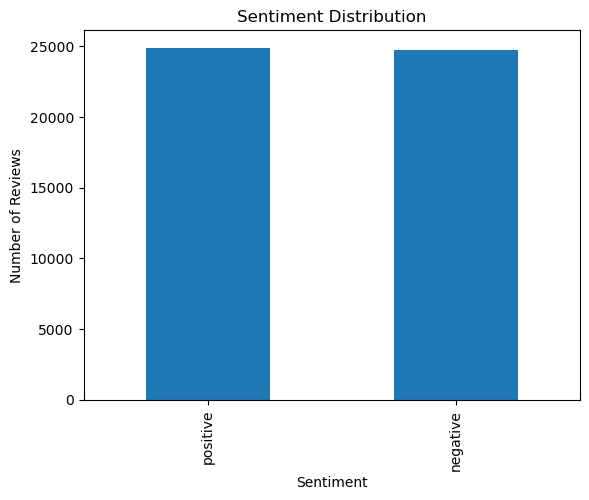

In [26]:
sentiment_counts.plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [27]:
total = len(df)

for sentiment, count in sentiment_counts.items():
    print(f"{sentiment}: {round((count/total)*100, 2)}%")

positive: 50.19%
negative: 49.81%


In [28]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_review'] = df['clean_review'].apply(clean_text)

In [29]:
all_words = " ".join(df['clean_review']).split()

word_counts = Counter(all_words)

common_words = word_counts.most_common(10)

print(common_words)

[('the', 658974), ('and', 318442), ('a', 318408), ('of', 286429), ('to', 264943), ('is', 209082), ('in', 183721), ('it', 153750), ('i', 150877), ('this', 148729)]


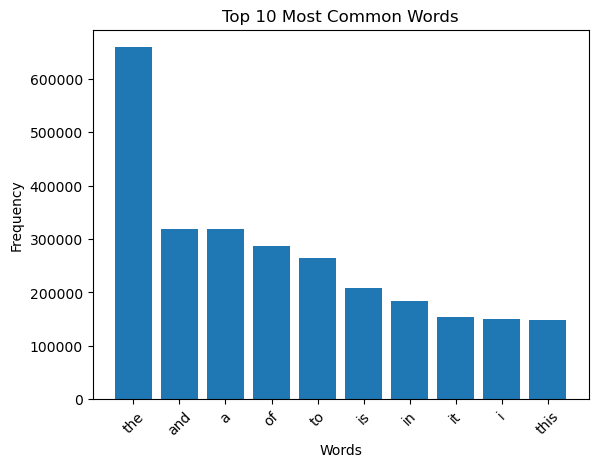

In [30]:
words = [word for word, count in common_words]
counts = [count for word, count in common_words]

plt.bar(words, counts)

plt.title("Top 10 Most Common Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()